In [1]:
# load necessary libraries and disable some warnings
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer
import torch
import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from pathlib import Path

project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.preprocessing import create_category_regex, match_dictionary
from utils.clustering import ModelMask, get_mask_embedding, find_opt_k
from utils.visualizations import (plot_embeddings_grid,
                                  plot_clustering_dev,
                                  static_mentions_boxplot,
                                  interactive_mentions_boxplot)

# load the dictionary terms
groups_dict_wide = pd.read_csv("../01_data/classification/dictionary/groups_dictionary_cl.csv")

## **Prepare Data, Load and Apply Model to Dictionary**

In [2]:
# create lists for all dictionary entries and their category names
mention_list = []
category_list = []
categories = groups_dict_wide.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dict_wide[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

# create long df based on these lists
groups_dict_long = pd.DataFrame({'mention': mention_list, 'category': category_list})

# load model from checkpoint
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMask(tokenizer).to(device)
model.load_state_dict(torch.load(f="model_checkpoint/checkpoint.pt", map_location=torch.device("mps")))

# apply model to all dictionary entries
dictionary_embeddings = get_mask_embedding(model, mention_list, tokenizer, device)

## **Visualize Clusters Without and With Contrastive Finetuning**

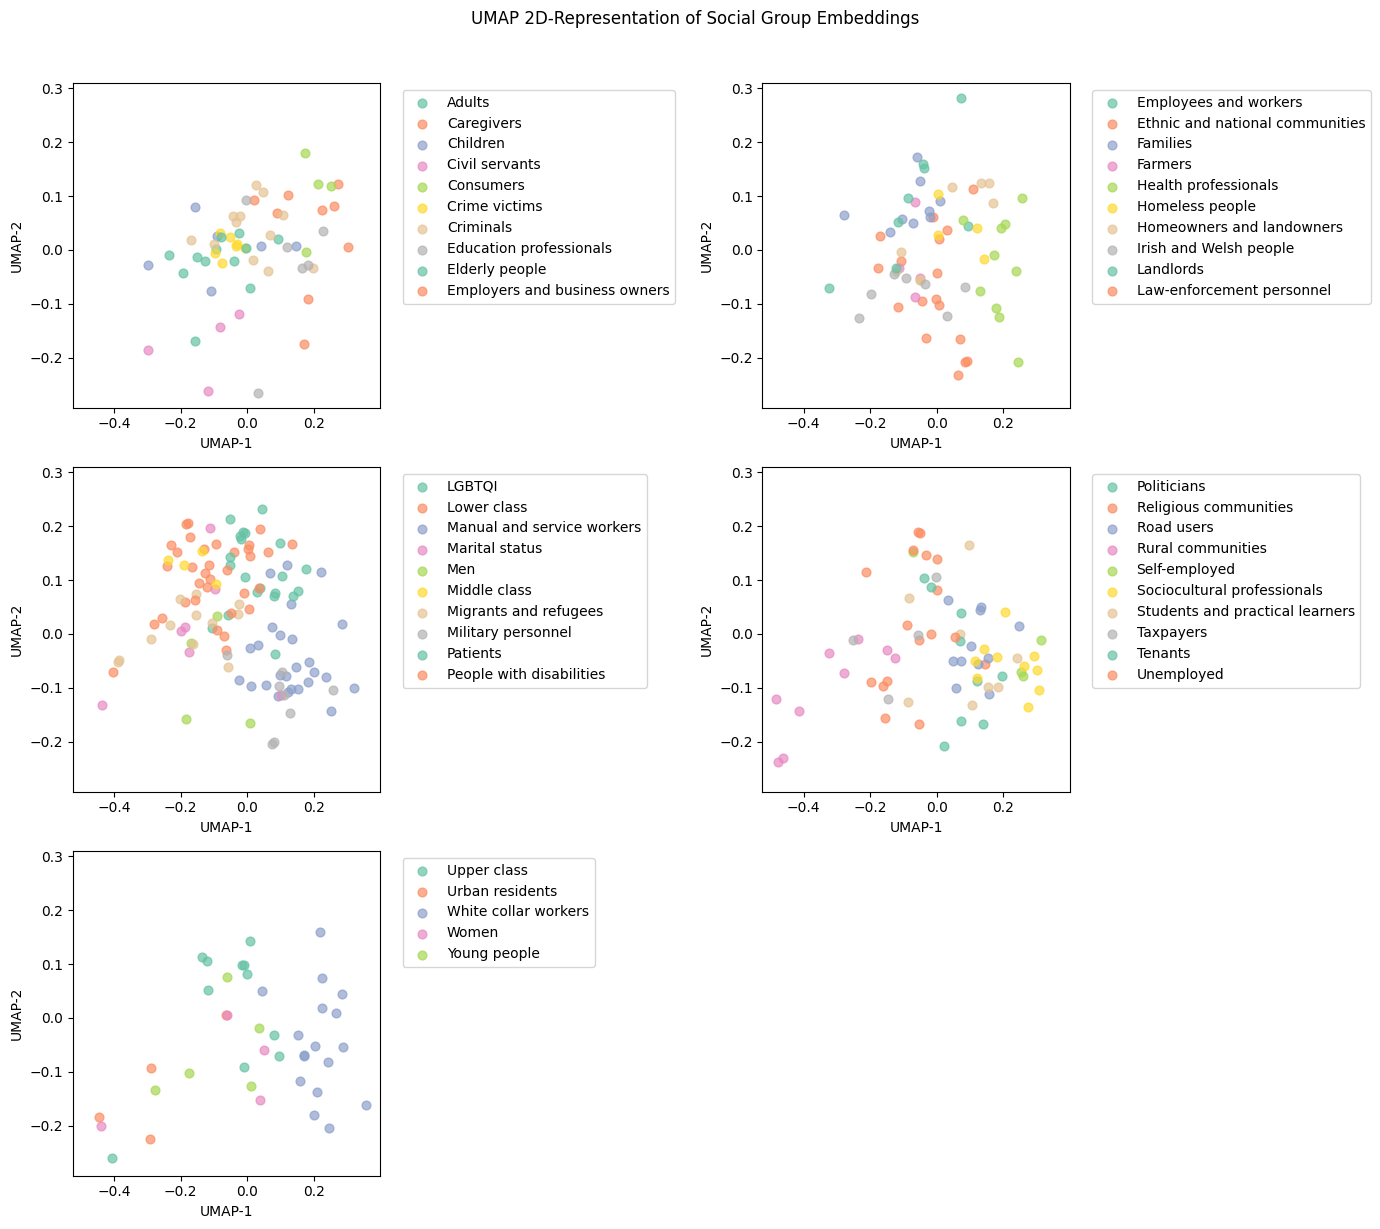

In [3]:
# create a fresh model instance and get embeddings from this model
model_without_cl = ModelMask(tokenizer).to(device)
emb_without_cl = get_mask_embedding(model_without_cl, mention_list, tokenizer, device)

# initialize umap reducer and apply to the embeddings
umap_reducer = umap.UMAP(n_components=2)
pca_reducer = PCA(n_components=2)

plot_embeddings_grid(
    reducer=pca_reducer,
    embeddings=emb_without_cl,
    category_list=category_list,
    cat2id=cat2id,
    reducer_name="UMAP",
    classes_per_plot=10,
    ncols=2,
    color_scheme=plt.cm.Set2.colors
)

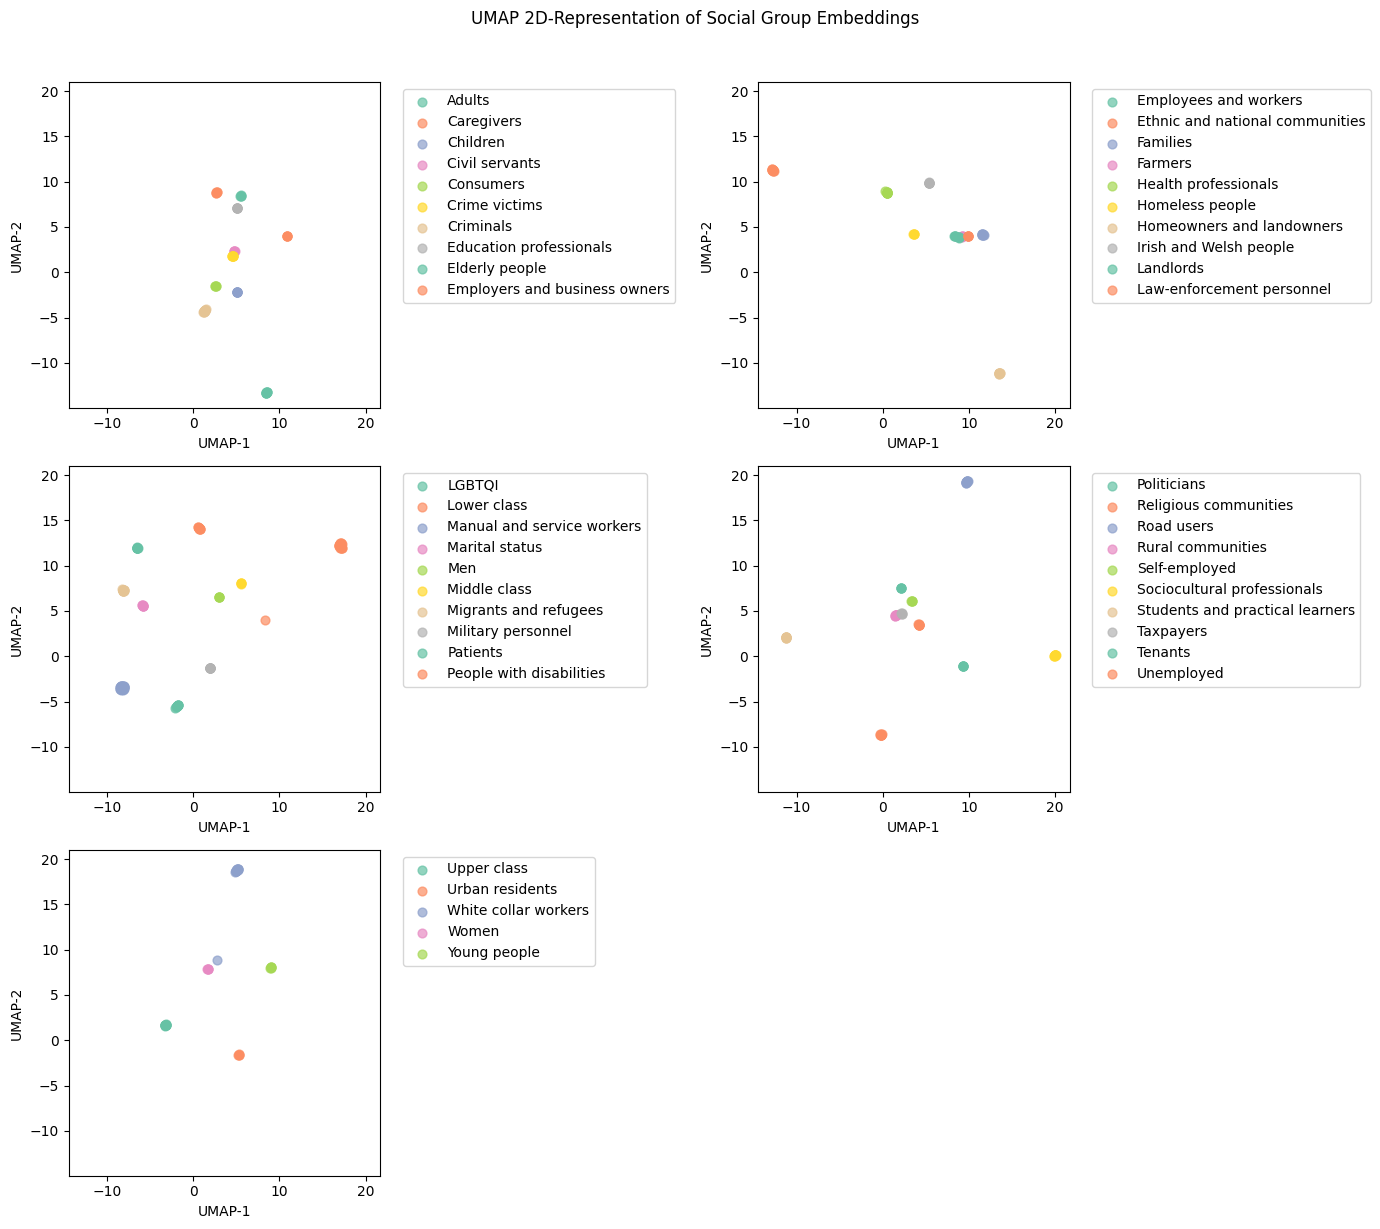

In [4]:
# create a fresh reducer and apply finetuned embeddings to it
umap_reducer = umap.UMAP(n_components=2)
pca_reducer = PCA(n_components=2)

# plot the 2d embeddings obtained from finetuned model
plot_embeddings_grid(
    reducer=umap_reducer,
    embeddings=dictionary_embeddings,
    category_list=category_list,
    cat2id=cat2id,
    reducer_name="UMAP",
    classes_per_plot=10,
    ncols=2,
    color_scheme=plt.cm.Set2.colors
)

## **Evaluate Cluster Quality of Dictionary Entries**

In [5]:
# cluster embeddings with DBSCAN and get silhouette score
X = dictionary_embeddings.numpy()

dbscan_model = DBSCAN(
    eps=0.3,
    min_samples=3,
    metric="euclidean"
)
pred_labels = dbscan_model.fit_predict(X)
dbscan_df = pd.DataFrame(
    {"mention": mention_list,
     "dbscan_cluster": pred_labels}
)
print(f"Silhouette score with DBSCAN cluster ids: {silhouette_score(X, pred_labels):.4f}")

Silhouette score with DBSCAN cluster ids: 0.9198


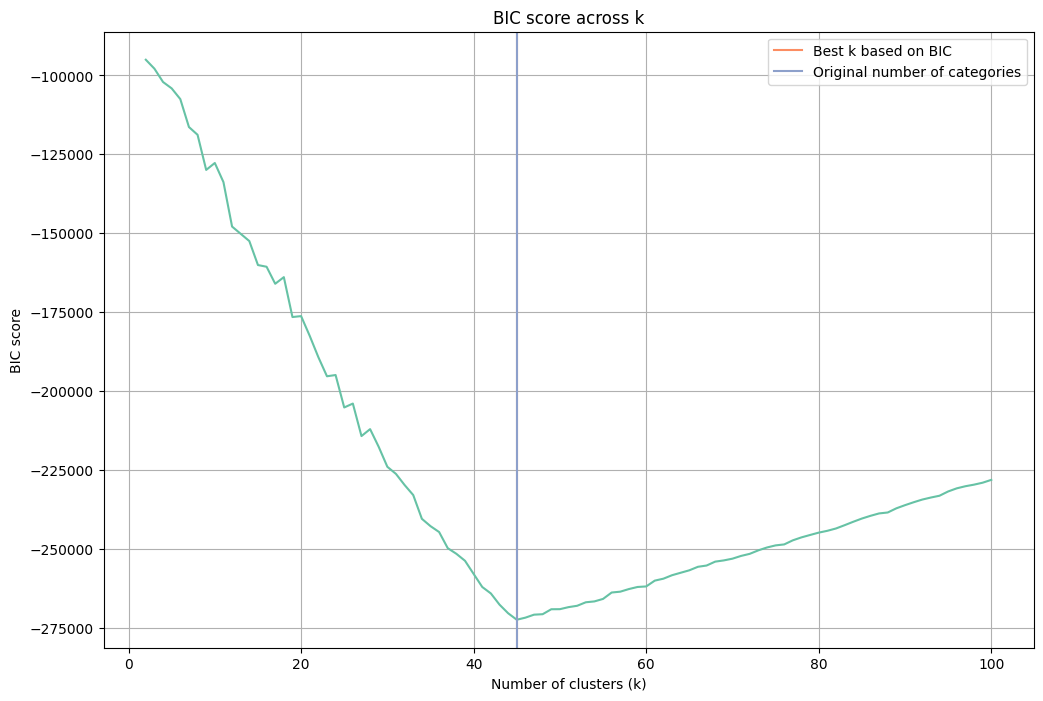

In [6]:
# create range of GMMs with increasing k and store the BIC
ks = range(2, 101)
bics = []
cov_type = 'diag'
for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=7,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500
    )
    gmm.fit(X)
    bics.append(gmm.bic(X))

_, _ = plot_clustering_dev(ks=ks, metrics_list=bics, metric_name="BIC", min_max="min", preknown_best_k=45, color_scheme=plt.cm.Set2.colors)

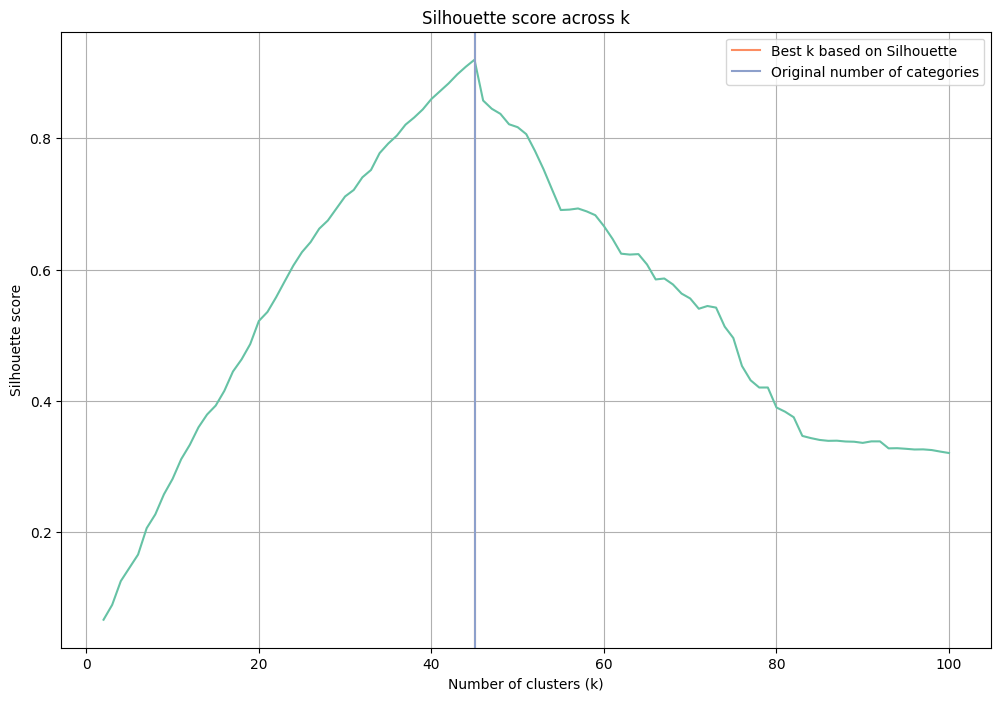

In [7]:
# create range of k-means models with increasing k and store the silhouette score 
ks = range(2, 101)

silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, pred_labels))

best_k, best_score = plot_clustering_dev(
    ks=ks,
    metrics_list=silhouette_scores,
    metric_name="Silhouette",
    min_max="max",
    preknown_best_k=45,
    color_scheme=plt.cm.Set2.colors)

In [8]:
# create k-means model with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=7)
pred_labels = kmeans.fit_predict(X)
groups_dict_long["cluster"] = pred_labels

# compute external validation metrics based on ground truth labels
nmi = normalized_mutual_info_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)
ari = adjusted_rand_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)

# print all metrics for the dictionary evaluation
print(f"Silhouette score: {best_score:.4f}")
print(f"NMI score: {nmi:.4f}")
print(f"ARI score: {ari:.4f}")

Silhouette score: 0.9198
NMI score: 0.9950
ARI score: 0.9863


## **Apply Model to Annotation Data**

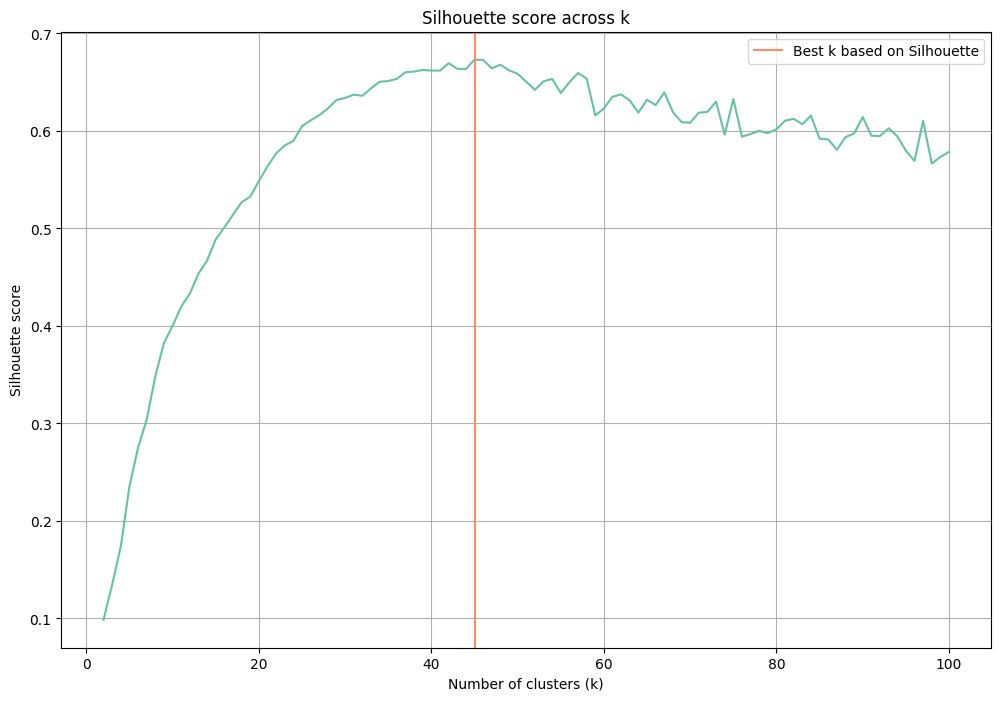

In [9]:
# import all annotations
with open("../01_data/classification/annotations/annotations_no_augmentations.json") as f:
    all_annotations = json.load(f)

# get all individual group mentions and create df
annotation_mentions = [ann["text"] for task in all_annotations for ann in task["annotations"] if task["annotations"]]
annotations_df = pd.DataFrame({"mention": annotation_mentions, "category": "Unknown"})

# load the original groups dictionary
groups_dict_original = pd.read_csv("../01_data/classification/dictionary/groups_dictionary.csv")

# create lookup regex and apply to the df
category_regex, group_lookup = create_category_regex(groups_dict_original)
annotations_df[["in_dictionary", "category"]] = annotations_df["mention"].apply(lambda x: pd.Series(match_dictionary(category_regex, group_lookup, x)))

# pass all mentions through the model
annotation_embeddings = get_mask_embedding(model, annotation_mentions, tokenizer, device)

# get the annotation embeddings as a numpy array
X = annotation_embeddings.numpy()

# set range of ks to evaluate
num_potential_clusters = 100
ks = list(range(2, num_potential_clusters+1))

# empty lists to store internal and external validation metrics
silhouette_scores = []
nmi_scores = []
ari_scores = []

# get mask for indicating which terms appear in dictionary
dict_mask = annotations_df["in_dictionary"].values
# get all categories for dictionary terms
dict_categories = annotations_df.loc[dict_mask, "category"].values

# loop over k
for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10,
        max_iter=300
    )

    # fit and predict cluster for all embeddings
    pred_labels = kmeans.fit_predict(X)

    # compute scores
    sil_score = silhouette_score(X, pred_labels)
    nmi = normalized_mutual_info_score(
        dict_categories,
        pred_labels[dict_mask]
    )
    ari = adjusted_rand_score(
        dict_categories,
        pred_labels[dict_mask]
    )

    # append all scores to their lists
    silhouette_scores.append(sil_score)
    nmi_scores.append(nmi)
    ari_scores.append(ari)

# plot development of silhouette scores
_, _ = plot_clustering_dev(
    ks=ks,
    metrics_list=silhouette_scores,
    metric_name="Silhouette",
    min_max="max",
    preknown_best_k=None,
    color_scheme=plt.cm.Set2.colors
    )

In [15]:
best_k, silscore = find_opt_k(ks, silhouette_scores, nmi_scores, 0.95)
print(f"Best k based on silhouette score and NMI: {best_k}")

# run model with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=7)
labels = kmeans.fit_predict(X)
annotations_df["kmeans_cluster"] = labels

# reduce df to only the dictionary matches
annotations_df_dict = annotations_df[annotations_df["in_dictionary"] == True]

# create contingency table
contingency = pd.crosstab(
    annotations_df_dict["category"], annotations_df_dict["kmeans_cluster"]
)

# calculate purity and homogeneity
category_purity = contingency.max(axis=1) / contingency.sum(axis=1)
cluster_homogeneity = contingency.max(axis=0) / contingency.sum(axis=0)
mean_purity = np.mean(category_purity)

# calculate nmi and ari for the kmeans clustering
nmi_kmeans = normalized_mutual_info_score(
    annotations_df_dict["category"],
    annotations_df_dict["kmeans_cluster"]
)
ari_kmeans = adjusted_rand_score(
    annotations_df_dict["category"],
    annotations_df_dict["kmeans_cluster"]
)

print("\nValidation metrics for k-means clustering")
print("-"*80)
print(f"Silhouette score: {silscore:.4f}")
print(f"Mean purity: {mean_purity:.4f}")
print(f"NMI score: {nmi_kmeans:.4f}")
print(f"ARI score: {ari_kmeans:.4f}")

# run dbscan clustering
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=3,
    metric="euclidean"
)
dbscan_labels = dbscan_model.fit_predict(X)

# get copy of the df for dbscan evaluation
dbscan_df = annotations_df.copy()
dbscan_df["dbscan_cluster"] = dbscan_labels

# get noise mask
non_noise_mask = dbscan_df["dbscan_cluster"] != -1

# print number of noise rows
print(f"\nSize of the noise cluster: {sum(non_noise_mask == False)}")
print(f"Overall data points: {len(dbscan_df)}")

# get predicted non-noise clusters
non_noise_clusters = dbscan_df.loc[non_noise_mask, "dbscan_cluster"].values

# compute silhouette score
silscore_dbscan = silhouette_score(X[non_noise_mask], non_noise_clusters)

# remove noise rows
dbscan_df_no_noise = dbscan_df[non_noise_mask]

# get only the rows with dictionary terms
dbscan_df_dict_no_noise = dbscan_df_no_noise[dbscan_df_no_noise["in_dictionary"] == True]

# calculate nmi and ari for the dbscan clustering
nmi_dbscan = normalized_mutual_info_score(
    dbscan_df_dict_no_noise["category"],
    dbscan_df_dict_no_noise["dbscan_cluster"]
)
ari_dbscan = adjusted_rand_score(
    dbscan_df_dict_no_noise["category"],
    dbscan_df_dict_no_noise["dbscan_cluster"]
)

print("\nValidation metrics for DBSCAN clustering (after noise cluster removal)")
print("-"*80)
print(f"Silhouette score: {silscore_dbscan:.4f}")
print(f"NMI score: {nmi_dbscan:.4f}")
print(f"ARI score: {ari_dbscan:.4f}")

Best k based on silhouette score and NMI: 49

Validation metrics for k-means clustering
--------------------------------------------------------------------------------
Silhouette score: 0.6622
Mean purity: 0.9163
NMI score: 0.8916
ARI score: 0.8433

Size of the noise cluster: 343
Overall data points: 3604

Validation metrics for DBSCAN clustering (after noise cluster removal)
--------------------------------------------------------------------------------
Silhouette score: 0.6462
NMI score: 0.9207
ARI score: 0.8926


In [16]:
# filter for noise cluster mentions and print some mentions within it
noise_cluster_mentions = dbscan_df[dbscan_df["dbscan_cluster"] == -1]["mention"]
for idx in range(20):
    print(noise_cluster_mentions.iloc[idx])

neighbours
Vulnerable young people
child sex slaves
those who fail in their responsibilities
tenants who are active farmers
an office holder
people in Mali who need our support
political activists
skilled workers
all those whose jobs depend on visiting people's homes
householders and businesses in Exeter and throughout the south-west
those from ethnic minorities
former Remploy employees who find themselves in part-time or full-time work
constituents in Ashford
power engineers
People in Derbyshire
colleagues who lost their lives in the Province
managers in the National Offender Management Service
a conscientious employee
every English household


## **Cluster Interpretation**

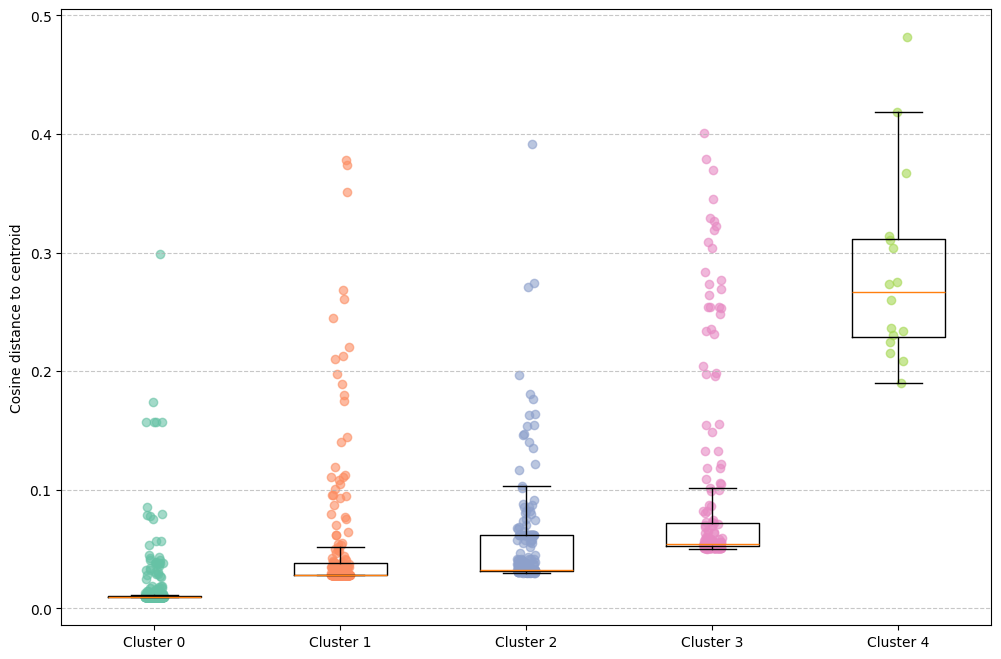

In [51]:
# get cluster centroids
centroids = kmeans.cluster_centers_

# cosine distance of each point to its assigned centroid
cos_sim = np.sum(X * centroids[labels], axis=1)
cos_dist = 1 - cos_sim
annotations_df["cosine_distance_to_centroid"] = cos_dist

static_mentions_boxplot(
    df=annotations_df, cluster_ids=range(5), cluster_col="kmeans_cluster", distance_col="distance_to_centroid", jitter=0.05, color_scheme=plt.cm.Set2.colors
)

In [57]:
interactive_mentions_boxplot(
    annotations_df,
    range(0, 5),
    "kmeans_cluster",
    distance_col="distance_to_centroid",
    mention_col="mention",
    color_scheme="Set2")